# Experiment 9 - Scenario 2

**Name:** SaiSanjay R  
**Roll No:** 24BAD102


### 1. IMPORT LIBRARIES
### 2. LOAD DATASET


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error


ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

### 3. CREATE ITEM-USER MATRIX


In [3]:
item_user_matrix = ratings.pivot_table(
    index='movieId',
    columns='userId',
    values='rating'
)

item_user_filled = item_user_matrix.fillna(0)

print("Item-User Matrix Shape:", item_user_filled.shape)


Item-User Matrix Shape: (9724, 610)


### 4. ITEM SIMILARITY (COSINE)


In [4]:
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_filled.index,
    columns=item_user_filled.index
)


### 5. TOP SIMILAR ITEMS


In [5]:
def get_similar_items(movie_id, n=5):
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    return sim_scores.iloc[1:n+1]

print("\nSimilar movies to movieId=1:")
print(get_similar_items(1))


Similar movies to movieId=1:
movieId
3114    0.572601
480     0.565637
780     0.564262
260     0.557388
356     0.547096
Name: 1, dtype: float64


### 6. RECOMMEND ITEMS BASED ON USER HISTORY


In [6]:
def recommend_items(user_id, n=5):

    user_ratings = ratings[ratings['userId'] == user_id]

    scores = {}

    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']

        similar_items = get_similar_items(movie, 10)

        for sim_movie, sim_score in similar_items.items():
            if sim_movie not in user_ratings['movieId'].values:
                scores[sim_movie] = scores.get(sim_movie, 0) + sim_score * rating

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    top_items = [movie_id for movie_id, _ in sorted_scores[:n]]

    return movies[movies['movieId'].isin(top_items)]

print("\nRecommendations for User 1:")
print(recommend_items(1, 5))



Recommendations for User 1:
      movieId                              title  \
337       380                   True Lies (1994)   
507       589  Terminator 2: Judgment Day (1991)   
902      1200                      Aliens (1986)   
1550     2087                   Peter Pan (1953)   
2195     2918    Ferris Bueller's Day Off (1986)   

                                        genres  
337   Action|Adventure|Comedy|Romance|Thriller  
507                              Action|Sci-Fi  
902             Action|Adventure|Horror|Sci-Fi  
1550        Animation|Children|Fantasy|Musical  
2195                                    Comedy  


### 7. RMSE EVALUATION (FAST)


In [7]:
def evaluate_rmse(sample_size=500):

    sample = ratings.sample(sample_size, random_state=42)

    actual = []
    predicted = []

    for _, row in sample.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']

        user_data = ratings[ratings['userId'] == user]

        weighted_sum = 0
        similarity_sum = 0

        for _, r in user_data.iterrows():
            sim = item_similarity_df.loc[movie, r['movieId']]
            if sim > 0:
                weighted_sum += sim * r['rating']
                similarity_sum += sim

        if similarity_sum > 0:
            pred = weighted_sum / similarity_sum

            actual.append(true_rating)
            predicted.append(pred)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("\nRMSE:", rmse)

evaluate_rmse()


RMSE: 0.9250189172879644


### 8. PRECISION@K


In [8]:
def precision_at_k(user_id, k=5, threshold=4.0):

    recs = recommend_items(user_id, k)
    rec_movie_ids = recs['movieId'].values

    user_data = ratings[ratings['userId'] == user_id]

    relevant = user_data[user_data['rating'] >= threshold]['movieId'].values

    hit = sum([1 for movie in rec_movie_ids if movie in relevant])

    precision = hit / k

    print(f"\nPrecision@{k}:", precision)

precision_at_k(1)



Precision@5: 0.0


### ANALYSIS
### Popular vs niche


In [9]:

movie_counts = ratings['movieId'].value_counts()

print("\nMost Popular Movies:")
print(movie_counts.head())

print("\nLeast Popular Movies:")
print(movie_counts.tail())


Most Popular Movies:
movieId
356     329
318     317
296     307
593     279
2571    278
Name: count, dtype: int64

Least Popular Movies:
movieId
188833    1
189381    1
3899      1
2848      1
147002    1
Name: count, dtype: int64


### VISUALIZATION
### 1. ITEM SIMILARITY HEATMAP
### 2. TOP SIMILAR ITEMS GRAPH


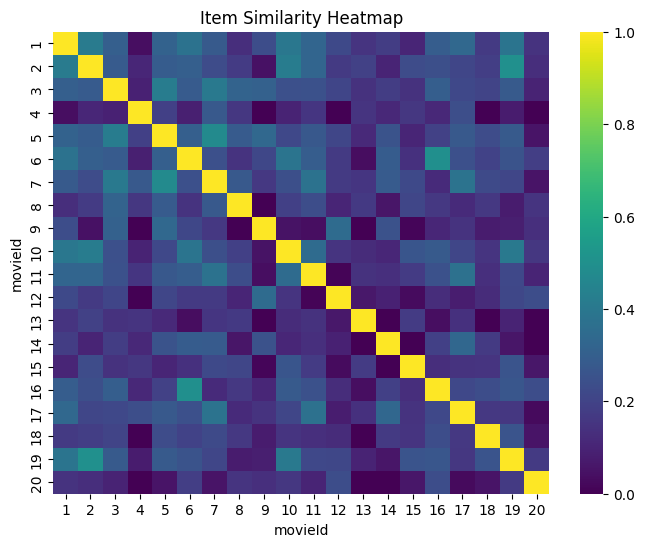

In [10]:

plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("Item Similarity Heatmap")
plt.show()


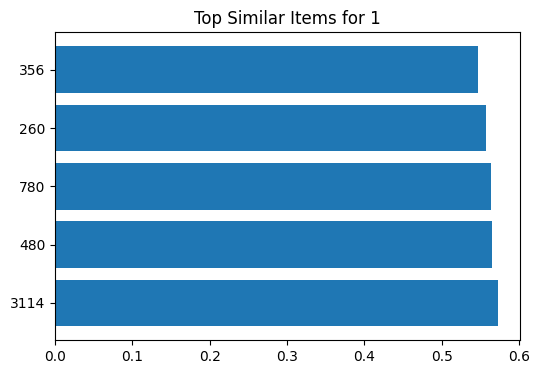

In [11]:
def plot_similar_items(movie_id):
    sims = get_similar_items(movie_id, 5)

    plt.figure(figsize=(6,4))
    plt.barh(sims.index.astype(str), sims.values)
    plt.title(f"Top Similar Items for {movie_id}")
    plt.show()

plot_similar_items(1)

### 3. RECOMMENDATION COMPARISON (USER vs ITEM)


In [12]:
def compare_user_item(user_id):
    item_recs = recommend_items(user_id, 5)

    print("\nItem-Based Recommendations:")
    print(item_recs[['title']])

compare_user_item(1)


Item-Based Recommendations:
                                  title
337                    True Lies (1994)
507   Terminator 2: Judgment Day (1991)
902                       Aliens (1986)
1550                   Peter Pan (1953)
2195    Ferris Bueller's Day Off (1986)
